<a href="https://colab.research.google.com/github/FarzamAmeer32/Machine-Learning-Titanic-survival-Prediction/blob/main/Titanic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Getiing basic info


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#Co Relation of features wrt to target
df.select_dtypes(exclude=object).corr()['Survived']

,Survived
PassengerId,-0.005007
Survived,1.000000
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
Parch,0.081629
Fare,0.257307


Exploring Distribution of data


In [ ]:
num_cols=df.select_dtypes(exclude='object')

In [ ]:
co_matrix=num_cols.corr()


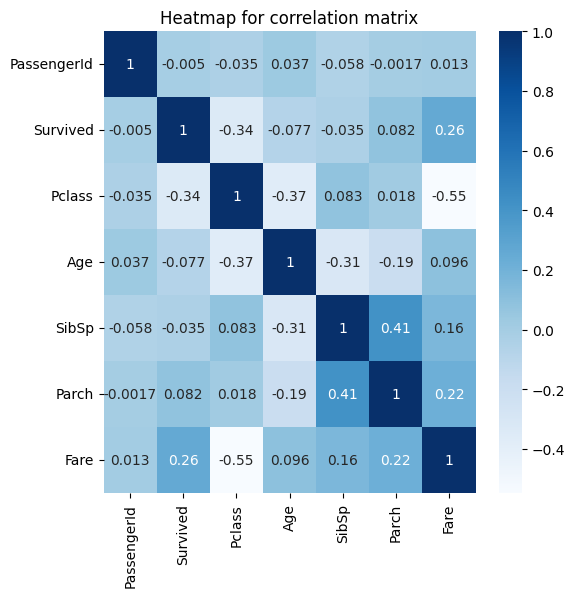

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(co_matrix,cmap='Blues',annot=True)
plt.title('Heatmap for correlation matrix')
plt.show()



In [ ]:
#less multi colinearity
#only sibsp and parch are mid corelated


Text(0.5, 1.0, 'Distribution of survived\n Survived\n0    549\n1    342\nName: count, dtype: int64')

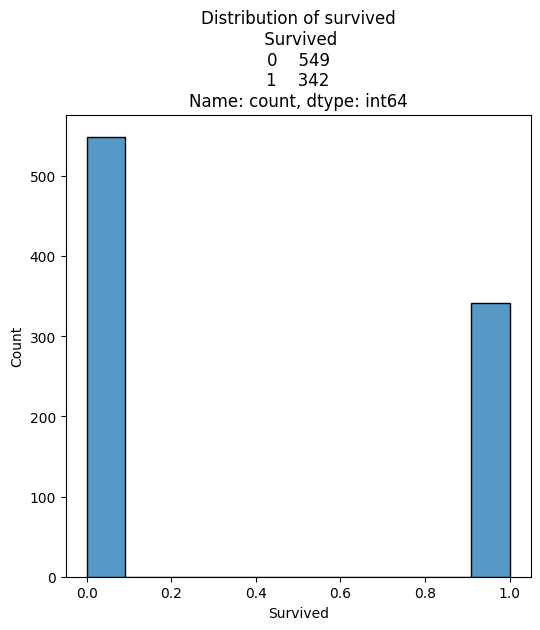

In [ ]:
plt.figure(figsize=(6,6))

sns.histplot(data=df,x=df.Survived)
plt.title(f'Distribution of survived\n {df['Survived'].value_counts()}')


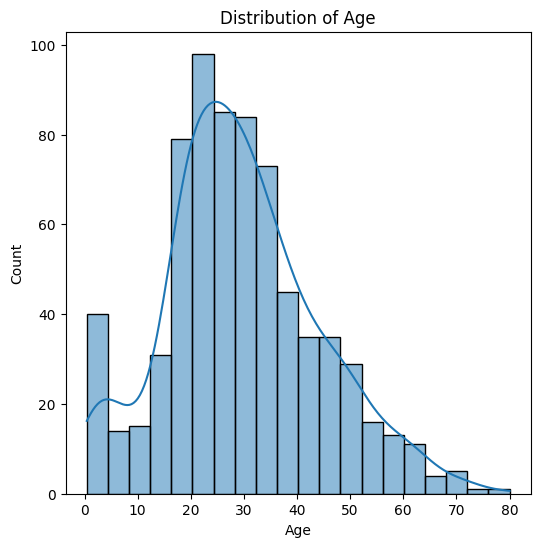

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.Age,kde=True)
plt.title('Distribution of Age')
plt.show()


In [ ]:
df.Age.skew()
#not a big skewed data

np.float64(0.38910778230082704)

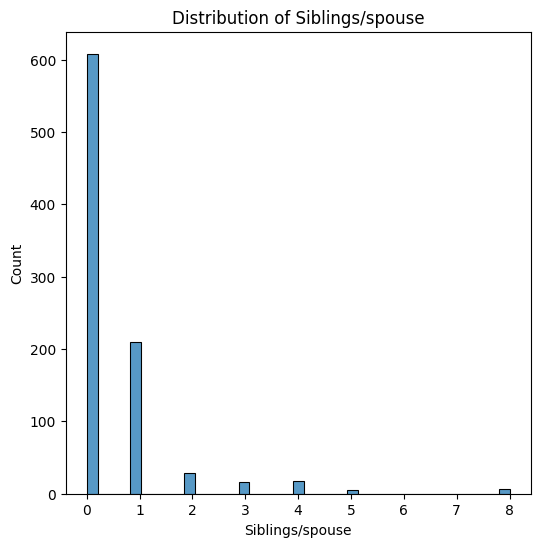

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.SibSp)
plt.xlabel('Siblings/spouse')
plt.title('Distribution of Siblings/spouse')
plt.show()

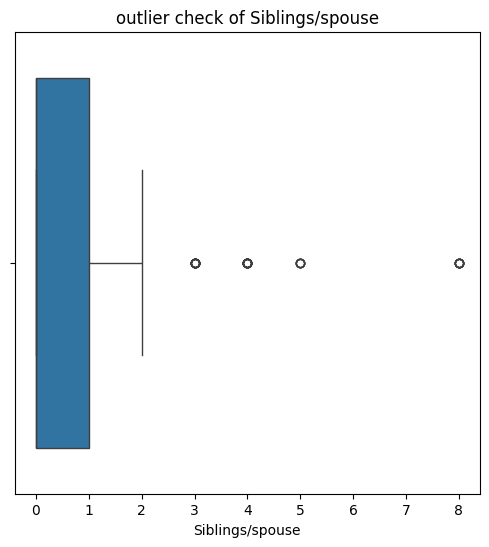

array([0., 1.])

In [ ]:
#outliers exist

plt.figure(figsize=(6,6))
sns.boxplot(data=df,x=df.SibSp)
plt.xlabel('Siblings/spouse')
plt.title('outlier check of Siblings/spouse')
plt.show()
np.percentile(df.SibSp,[25,75])

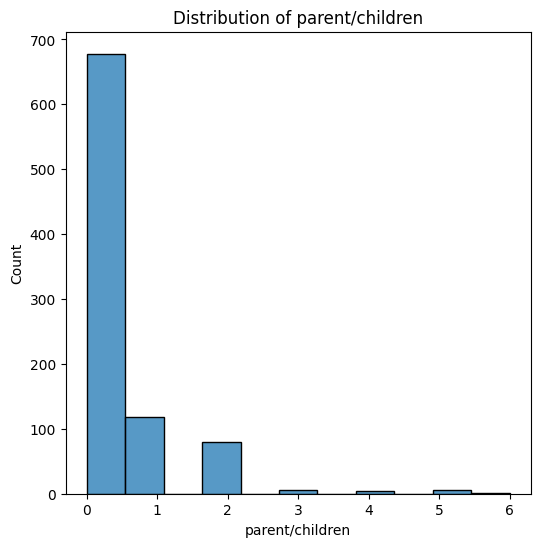

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.Parch)
plt.xlabel('parent/children')
plt.title('Distribution of parent/children')
plt.show()

Text(0.5, 1.0, 'outlier check of parent/children')

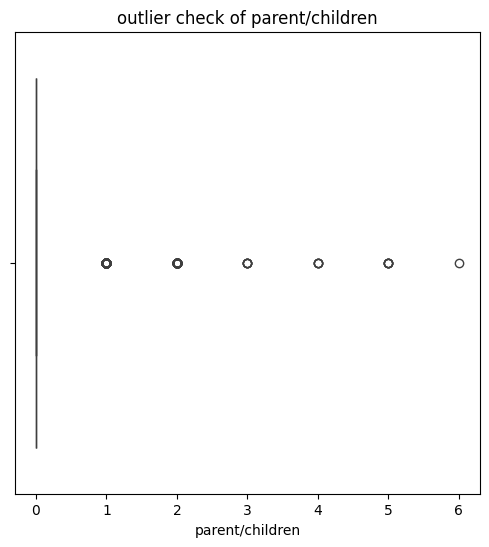

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df,x=df.Parch)
plt.xlabel('parent/children')
plt.title('outlier check of parent/children')


In [ ]:
#less variation more outliers

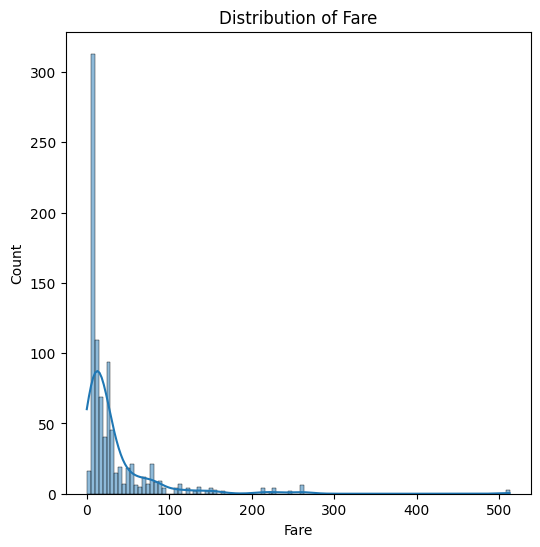

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.Fare,kde=True)
plt.xlabel('Fare')
plt.title('Distribution of Fare')
plt.show()

Text(0.5, 1.0, 'oulier check of Fare')

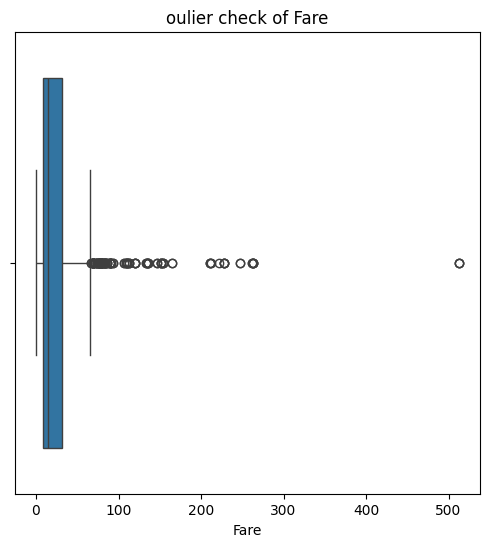

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df,x=df.Fare)
plt.xlabel('Fare')
plt.title('oulier check of Fare')

In [ ]:
df.Fare.skew()


np.float64(4.787316519674893)

In [ ]:
df['normalFare']=np.log1p(df.Fare)


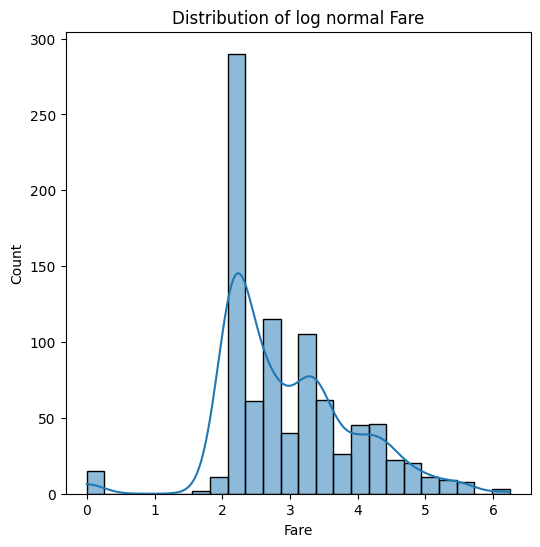

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.normalFare,kde=True)
plt.xlabel('Fare')
plt.title('Distribution of log normal Fare')
plt.show()

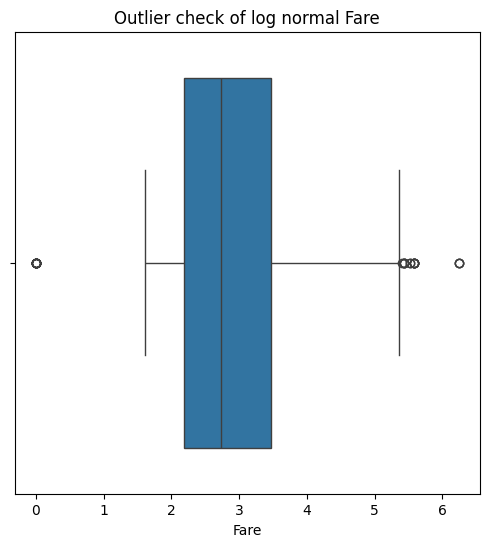

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df,x=df.normalFare)
plt.xlabel('Fare')
plt.title('Outlier check of log normal Fare')
plt.show()

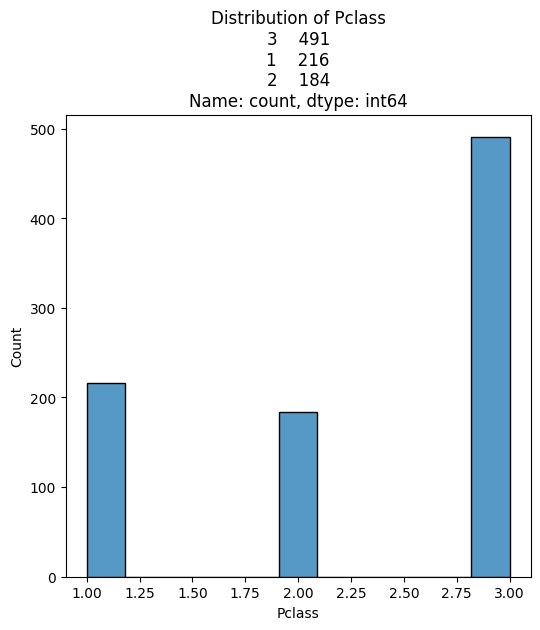

In [ ]:
#checking distribution for p-Class
plt.figure(figsize=(6,6))
sns.histplot(data=df,x=df.Pclass)
plt.xlabel('Pclass')
plt.title(f'Distribution of {df.Pclass.value_counts()}')
plt.show()


In [ ]:
df.groupby(['Pclass','Survived'])['Fare'].agg(['mean','count'])

mean  count
Pclass Survived                  
1      0         64.684007     80
       1         95.608029    136
2      0         19.412328     97
       1         22.055700     87
3      0         13.669364    372
       1         13.694887    119

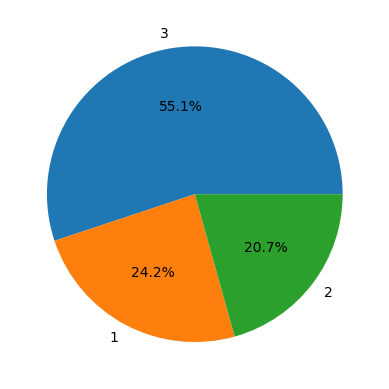

In [ ]:
#class Imbalance
plt.pie(df.Pclass.value_counts(),labels=df.Pclass.value_counts().index,autopct='%1.1f%%')
plt.show()


In [ ]:
df.groupby(['Pclass','Survived'])['Survived'].count()
#mot people survived on 1 and died on 3 but 2 seems balanced


Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

In [ ]:
print(df.groupby('Survived')['Fare'].mean())
print(df.groupby('Survived')['Fare'].describe())
#most people who paid high fares survived but we also have overlapping values

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [ ]:
df.groupby('Survived')['Age'].mean()
df.groupby('Survived')['Age'].describe()
#again overlapping
df.groupby(['Survived','Sex'])['Age'].mean()


Survived  Sex   
0         female    25.046875
          male      31.618056
1         female    28.847716
          male      27.276022
Name: Age, dtype: float64

In [ ]:
df.groupby(['Survived'])['SibSp'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,0.553734,1.288399,0.0,0.0,0.0,1.0,8.0
1,342.0,0.473684,0.708688,0.0,0.0,0.0,1.0,4.0


In [ ]:
df.groupby(['Survived'])['Parch'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,0.329690,0.823166,0.0,0.0,0.0,0.0,6.0
1,342.0,0.464912,0.771712,0.0,0.0,0.0,1.0,5.0


In [ ]:
#people with fewer family members did survived more---

Fare is highly right-skewed and requires log transformation
Age has mild skewness; missing value imputation is more important
Target variable (Survived) shows moderate class imbalance
Pclass is ordinal and unevenly distributed (majority in 3rd class)
SibSp and Parch are zero-inflated and better combined into FamilySize


getting some info on categorical features

In [ ]:
cat_cols=df.select_dtypes(include='object')
cat_cols

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,NaN,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [ ]:
#we know sex has 2 discrete values
df.groupby('Sex')['Sex'].count()

,Sex
Sex,
female,314
male,577


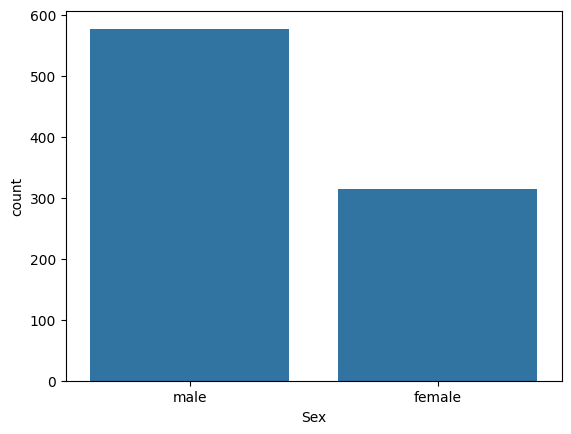

In [ ]:
sns.countplot(data=df,x=df.Sex)
plt.show()

In [ ]:
df.groupby(['Sex','Survived'])['Survived'].count()
#most males died
#most females survived
#we saw this is the movies too - 'females and children first'

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [ ]:
# we can see that every person has a title assigned to it- we have to drop name feature at some point otherwise encoding it will create many dimensions- so we extract titles
df.Name[df['Name'].str.contains('Mr|Mrs|Miss|Master', case=False, na=False)]

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
885,"Rice, Mrs. William (Margaret Norton)"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [ ]:
df.Name[~df['Name'].str.contains('Mr|Mrs|Miss|Master', case=False, na=False)]
#these represent people of higher status

,Name
30,"Uruchurtu, Don. Manuel E"
149,"Byles, Rev. Thomas Roussel Davids"
150,"Bateman, Rev. Robert James"
245,"Minahan, Dr. William Edward"
249,"Carter, Rev. Ernest Courtenay"
317,"Moraweck, Dr. Ernest"
369,"Aubart, Mme. Leontine Pauline"
398,"Pain, Dr. Alfred"
443,"Reynaldo, Ms. Encarnacion"
449,"Peuchen, Major. Arthur Godfrey"


In [ ]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False) # regex extraction took from chatgpt
df.Title.value_counts()
df.Title.nunique()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_28905/1186724092.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False) # regex extraction took from chatgpt


17

In [ ]:
df.groupby(['Title','Sex','Survived'])['Survived'].count()

Title     Sex     Survived
Capt      male    0             1
Col       male    0             1
                  1             1
Countess  female  1             1
Don       male    0             1
Dr        female  1             1
          male    0             4
                  1             2
Jonkheer  male    0             1
Lady      female  1             1
Major     male    0             1
                  1             1
Master    male    0            17
                  1            23
Miss      female  0            55
                  1           127
Mlle      female  1             2
Mme       female  1             1
Mr        male    0           436
                  1            81
Mrs       female  0            26
                  1            99
Ms        female  1             1
Rev       male    0             6
Sir       male    1             1
Name: Survived, dtype: int64

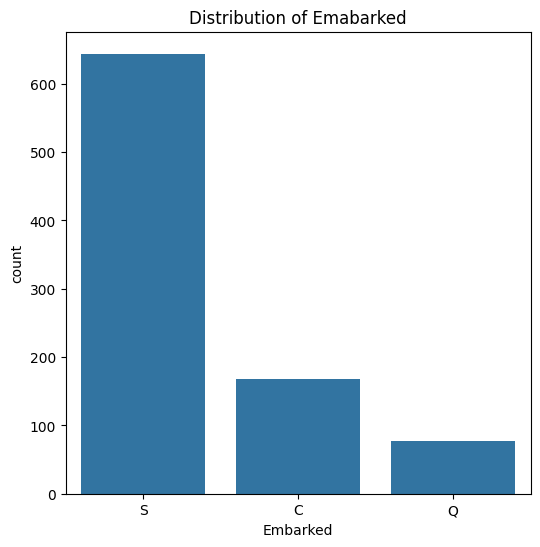

In [ ]:
#Embarked
plt.figure(figsize=(6,6))


sns.countplot(x='Embarked',data=df)
plt.title('Distribution of Emabarked')
plt.show()



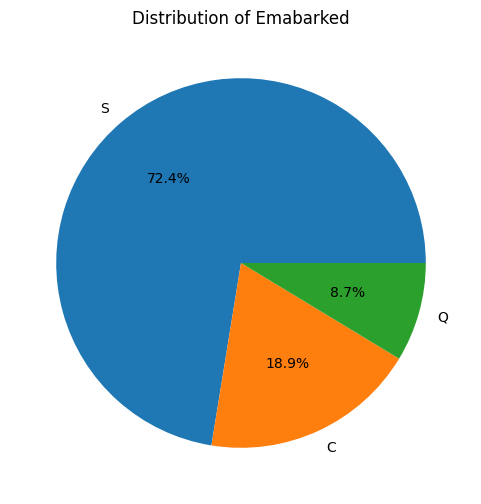

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(df.Embarked.value_counts(),labels=df.Embarked.value_counts().index,autopct='%1.1f%%')
plt.title('Distribution of Emabarked')
plt.show()

In [ ]:
df.groupby(['Embarked','Survived'])['Survived'].count()

Embarked  Survived
C         0            75
          1            93
Q         0            47
          1            30
S         0           427
          1           217
Name: Survived, dtype: int64

In [ ]:
# for cabin feature- we know from the movie that lower deck mostly died whereas upper deck survived
#has missing values- a lot
df['Deck']=df.Cabin.str[0]
df.groupby(['Deck','Survived'])['Deck'].count()
#this explains more rather than deck type


Deck  Survived
A     0            8
      1            7
B     0           12
      1           35
C     0           24
      1           35
D     0            8
      1           25
E     0            8
      1           24
F     0            5
      1            8
G     0            2
      1            2
T     0            1
Name: Deck, dtype: int64

In [ ]:
df['Cabin_known'] = df['Cabin'].fillna('').str.strip().ne('').astype(int)

In [ ]:
df.Cabin_known

,Cabin_known
0,0
1,1
2,0
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
df.Ticket.value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [ ]:
df['Ticket_prefix'] = df['Ticket'].str.split().str[0]
df.groupby('Ticket_prefix')['Ticket'].count()


,Ticket
Ticket_prefix,
110152,3
110413,3
110465,2
110564,1
110813,1
...,...
SW/PP,1
W./C.,9
W.E.P.,1


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,normalFare,Title,Deck,Cabin_known,Ticket_prefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2.110213,Mr,NaN,0,A/5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593,Mrs,C,1,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.188856,Miss,NaN,0,STON/O2.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834,Mrs,C,1,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2.202765,Mr,NaN,0,373450


Applying valueable insights from above to train model


In [ ]:
train_df=pd.read_csv('train.csv')
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
#data splitting
X=train_df.drop('Survived',axis=1)
y=train_df['Survived']
print(X.head())
print(y.head())

   PassengerId  Pclass                                               Name  \
0            1       3                            Braund, Mr. Owen Harris   
1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3       3                             Heikkinen, Miss. Laina   
3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5       3                           Allen, Mr. William Henry   

      Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S  
1  female  38.0      1      0          PC 17599  71.2833   C85        C  
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
3  female  35.0      1      0            113803  53.1000  C123        S  
4    male  35.0      0      0            373450   8.0500   NaN        S  
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
#Performing a train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)




In [ ]:
#defining a function for feature eng that runs inside pipeline
def feature_eng(x):
  x=x.copy()
  #dropping passenger
  if 'PassengerId' in x.columns:
    x.drop('PassengerId',axis=1,inplace=True)

  #creating family_size
  x['Family_size']=x['SibSp']+x['Parch']+1

  #if the person is alone or not
  x['is_alone']=(x['Family_size']==1).astype(int)

  #log normal fare

  x['normalFare']=np.log1p(x.Fare)

  # Title extraction
  x['Title'] = x['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

  # Group rare titles
  x['Title'] = x['Title'].replace(
        ['Capt','Col','Don','Dr','Jonkheer','Lady','Major','Rev','Sir','Countess','Mme','Ms','Mlle'],
        'Rare'
    )
  #getting deck
  x['Deck']=x['Cabin'].str[0]

  #creating a column for cabin as it has many missing vals
  x['Cabin_known'] = x['Cabin'].fillna('').str.strip().ne('').astype(int)

  x= x.drop(['Name','Ticket','Cabin'], axis=1)

  return x










<>:19: SyntaxWarning: invalid escape sequence '\.'
<>:19: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_28905/2663130066.py:19: SyntaxWarning: invalid escape sequence '\.'
  x['Title'] = x['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_size,is_alone,normalFare,Title,Deck,Cabin_known
0,0,3,male,22.0,1,0,7.2500,S,2,0,2.110213,Mr,NaN,0
1,1,1,female,38.0,1,0,71.2833,C,2,0,4.280593,Mrs,C,1
2,1,3,female,26.0,0,0,7.9250,S,1,1,2.188856,Miss,NaN,0
3,1,1,female,35.0,1,0,53.1000,S,2,0,3.990834,Mrs,C,1
4,0,3,male,35.0,0,0,8.0500,S,1,1,2.202765,Mr,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,1,2.639057,Rare,NaN,0
887,1,1,female,19.0,0,0,30.0000,S,1,1,3.433987,Miss,B,1
888,0,3,female,NaN,1,2,23.4500,S,4,0,3.196630,Miss,NaN,0
889,1,1,male,26.0,0,0,30.0000,C,1,1,3.433987,Mr,C,1


In [ ]:
feature_transformer=FunctionTransformer(feature_eng)

In [ ]:
num_cols=X_train.select_dtypes(exclude='object').columns
cat_cols=X_train.select_dtypes(include='object').columns
num_cols=num_cols.drop('PassengerId')
cat_cols=cat_cols.drop(['Name','Ticket','Cabin'])

In [ ]:
num_cols

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
cat_cols

Index(['Sex', 'Embarked'], dtype='object')

In [ ]:
#creating a pipeline for numerical and categorical features
num_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder())
])
preprocessor=ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])


In [ ]:
pipelines={
    'logistic':Pipeline(steps=[
        ('feature_eng',feature_transformer),
        ('preprocessor',preprocessor),
        ('Model',LogisticRegression(class_weight='balanced'))
    ]),
    'RandomForest':Pipeline(steps=[
        ('feature_eng',feature_transformer),
        ('preprocessor',preprocessor),
        ('Model',RandomForestClassifier(class_weight='balanced',criterion='gini'))
    ]),
    'SVC':Pipeline(steps=[
        ('feature_eng',feature_transformer),
        ('preprocessor',preprocessor),
        ('Model',SVC(class_weight='balanced'))
    ]),
    'XGB':Pipeline(steps=[
        ('feature_eng',feature_transformer),
        ('preprocessor',preprocessor),
        ('Model',XGBClassifier())
        ]),
    'GradientBoost':Pipeline(steps=[
        ('feature_eng',feature_transformer),
        ('preprocessor',preprocessor),
        ('Model',GradientBoostingClassifier())
        ])


}

In [ ]:
scores={}
for name,pipe in pipelines.items():
  pipe.fit(X_train,y_train)
  score=pipe.score(X_test,y_test)
  scores[name]=score



In [ ]:
scores

{'logistic': 0.8044692737430168,
 'RandomForest': 0.8044692737430168,
 'SVC': 0.8100558659217877,
 'XGB': 0.7988826815642458,
 'GradientBoost': 0.7988826815642458}

In [ ]:
#getting the three best scores
best_scores=sorted(scores.items(),key=lambda x:x[1],reverse=True)[:3]
best_scores=dict(best_scores)
print(best_scores)

{'SVC': 0.8100558659217877, 'logistic': 0.8044692737430168, 'RandomForest': 0.8044692737430168}


In [ ]:
#performing cross validation score to check

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores={}
best_models=list(best_scores.keys())


for model in best_models:
  pipe=pipelines[model]
  cv_score=cross_val_score(pipe,X_train,y_train,cv=5)
  score=cv_score.mean()
  cv_scores[model]=score



In [ ]:
cv_scores
#SVC is performing the best lets hyperparamter tune this

{'SVC': np.float64(0.8090416625627894),
 'logistic': np.float64(0.7837486457204766),
 'RandomForest': np.float64(0.793666896483798)}

In [ ]:

param_grid = {
    'Model__C': [0.1, 1, 10],
    'Model__gamma': [0.01, 0.1],
    'Model__kernel': ['rbf', 'linear']
}

In [ ]:
grid=GridSearchCV(pipelines['SVC'],param_grid=param_grid,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function feature_eng at 0x7b88a82d3f60>)),
                                       ('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder())]),
                                                                         Index(['Sex', 'Embarked'], dtype='object'))])),
                                       ('Model',
                                        SVC(class_weight='balanced'))]),
             param_grid={'Model__C': [0.1, 1, 10], 'Model__gamma': [0.01, 0.1],
                         'Model__kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'Model__C': 1, 'Model__gamma': 0.1, 'Model__kernel': 'rbf'}

In [ ]:
#grid.best_score_

np.float64(0.8146557667684429)

In [ ]:
#lets use these parameter with svc to train now on full train set
train_set=pd.read_csv('train.csv')
test_set=pd.read_csv('test.csv')


In [ ]:
final_pipeline_scv=Pipeline(steps=[
    ('feature_eng',feature_transformer),
    ('preprocessor',preprocessor),
    ('Model',SVC(class_weight='balanced',C=1,gamma=0.1,kernel='rbf'))
])

In [ ]:
x_train=train_set.drop('Survived',axis=1)
y_train=train_set['Survived']

In [ ]:
final_pipeline_scv.fit(x_train,y_train)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function feature_eng at 0x7b88a82d3f60>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  Index(['Sex', 'Embarked'], dtype='object'))])),
                ('Model', SVC(C=1, class_weight='balanced', gamma=0.1))])

In [ ]:
test_set.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test_set.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
#lets make our predictions
x_test=test_set
y_pred=final_pipeline_scv.predict(x_test)

In [ ]:
y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
submission=pd.DataFrame({
    'PassengerId':test_set['PassengerId'],
    'Survived':y_pred
})

In [ ]:
submission.to_csv('Submission_1.csv',index=False)

In [ ]:
#had 78 Accuracy on kaggle Sumbittion